In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import holidays

import ipywidgets as widgets
from ipywidgets import interact
import calendar

import warnings
warnings.filterwarnings("ignore")

# --- Set global Matplotlib parameters ---
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 1000
plt.rcParams["font.size"] = 20
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["legend.fontsize"] = 20
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 5.0
plt.rcParams["xtick.minor.size"] = 3.0
plt.rcParams["ytick.major.size"] = 5.0
plt.rcParams["ytick.minor.size"] = 3.0
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams["legend.handlelength"] = 2.0

In [16]:
import sys
sys.path.append("../")

from src.utils.utils import fill_missing_values, correct_outliers

In [17]:
data = pd.read_csv('.././data/data.csv')
print(data.head())

  shipped_date     sku channel  qty   revenue  cost of good sold  MOQ order
0     1/1/2021  089A0E     ADS  190   5027.40            2926.00      56460
1     1/1/2021  089A0E     AWH   30    793.80                NaN      56460
2     1/1/2021  0FKFLA     AWH  780  32028.36           13104.00     427545
3     1/1/2021  0G8Z4M     AWH   85   1307.81             595.00       2516
4     1/1/2021  0NFJ14     FBM   38   2127.47            1723.25      18734


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48363 entries, 0 to 48362
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   shipped_date       48363 non-null  object 
 1   sku                48363 non-null  object 
 2   channel            48363 non-null  object 
 3   qty                48363 non-null  int64  
 4   revenue            44099 non-null  float64
 5   cost of good sold  43311 non-null  float64
 6   MOQ order          48363 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 2.6+ MB


In [18]:
data.rename(columns={'cost of good sold': 'COGS','MOQ order':'MOQ_orders'}, inplace=True)

In [19]:
print(data['sku'].nunique())
print(data['shipped_date'].min())
print(data['shipped_date'].max())

676
1/1/2021
9/8/2021


In [21]:
print(data.shape)
data.isna().sum()

(48363, 7)


shipped_date       0
sku                0
channel            0
qty                0
revenue         4264
COGS            5052
MOQ_orders         0
dtype: int64

In [72]:
### fill missing values for easier EDA: 
data_filled = fill_missing_values(data)

In [73]:
#revenue still missing because it only have 1 day sales in the data --> so we remove it for now
data_filled = data_filled.dropna(subset=['revenue'])

#### Check and correct the outlier: 

In [74]:
data_filled['qty'].describe()

count    48335.000000
mean       260.425861
std        584.683467
min       -368.000000
25%         34.000000
50%         80.000000
75%        238.000000
max      18860.000000
Name: qty, dtype: float64

In [82]:
data_outliers_corrected = correct_outliers(data_filled, factor=3)

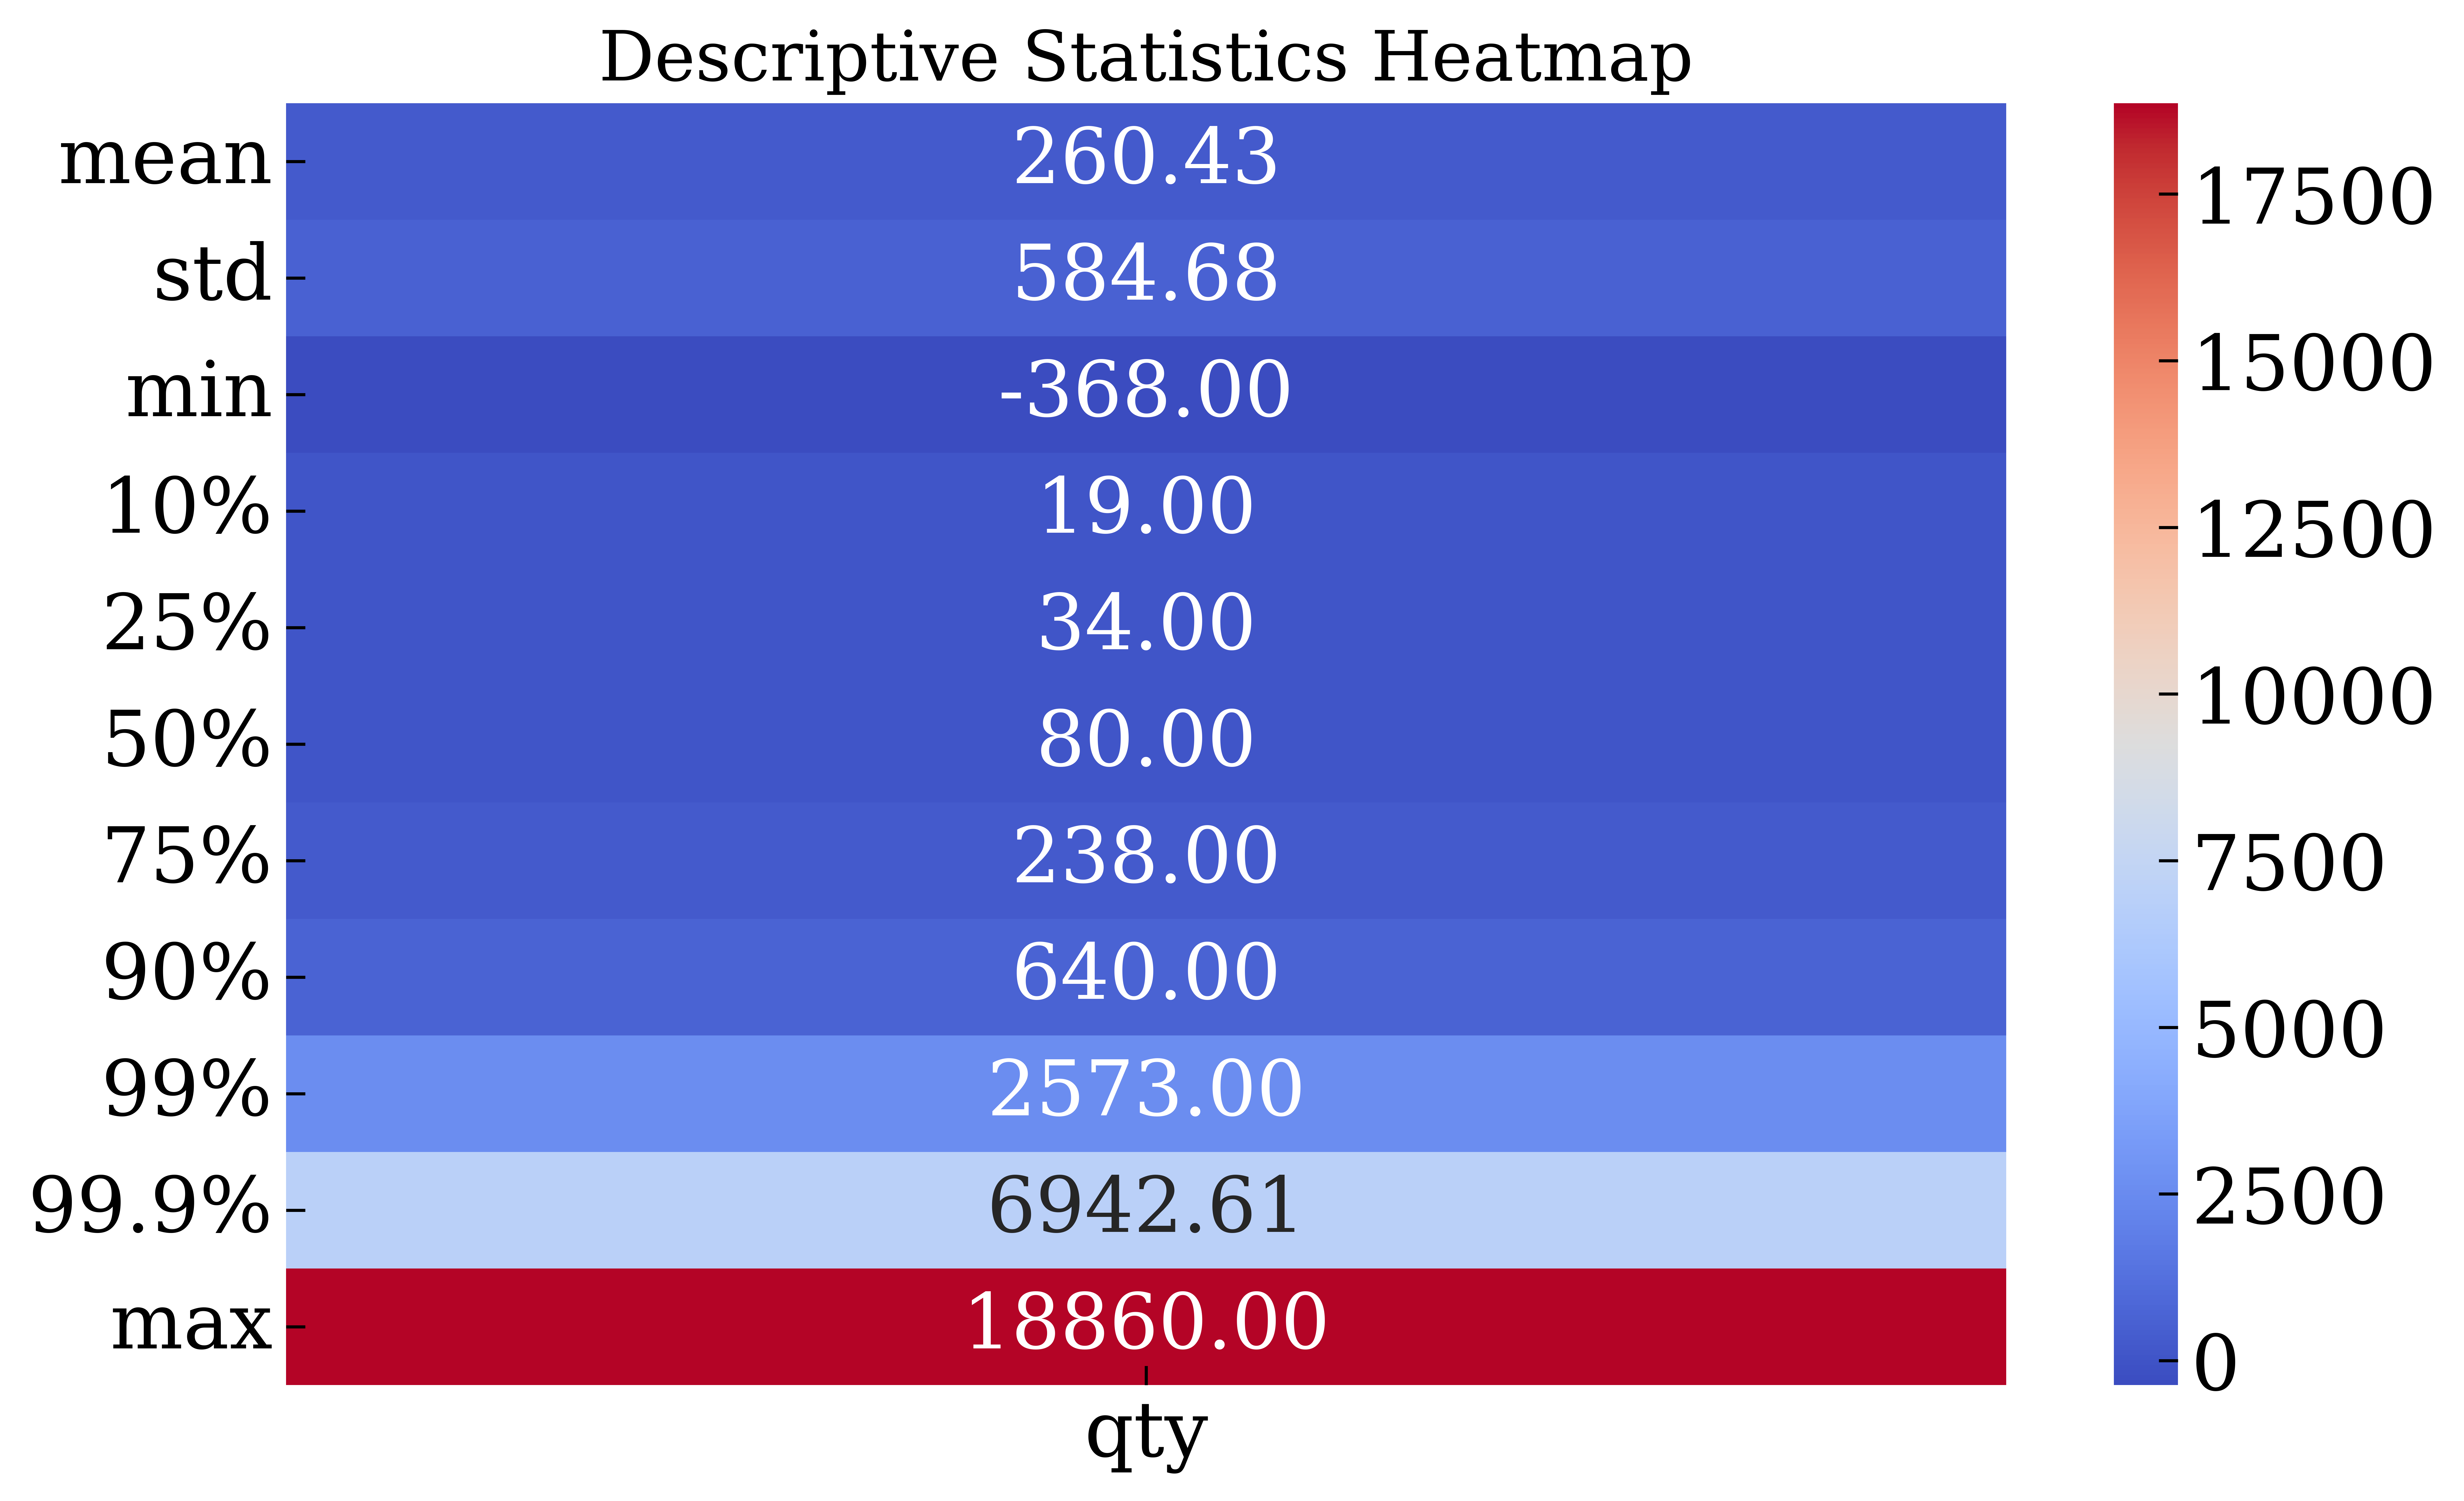

In [ ]:
# Using heat map to visualize outliers
summary = (
    data_filled[["sku", "qty", "revenue"]]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
    .iloc[1:]
)

plt.figure(figsize=(10, 6))
sns.heatmap(summary, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Descriptive Statistics Heatmap")
plt.show()

In [76]:
#remove the negative value for qty, which is likely a data entry error: 
data_filled = data_filled[data_filled['qty'] >= 0]

In [83]:
data_outliers_corrected.shape

(48332, 7)

#### add temporal data: 

In [84]:
data_outliers_corrected['shipped_date'] = pd.to_datetime(data_outliers_corrected['shipped_date'])
data_outliers_corrected['month'] = data_outliers_corrected['shipped_date'].dt.month
data_outliers_corrected['day'] = data_outliers_corrected['shipped_date'].dt.day
data_outliers_corrected['year'] = data_outliers_corrected['shipped_date'].dt.year
data_outliers_corrected['dayofweek'] = data_outliers_corrected['shipped_date'].dt.dayofweek
data_outliers_corrected['dayofyear'] = data_outliers_corrected['shipped_date'].dt.dayofyear
data_outliers_corrected['weekofyear'] = data_outliers_corrected['shipped_date'].dt.isocalendar().week
data_outliers_corrected['quarter'] = data_outliers_corrected['shipped_date'].dt.quarter

data_add_template = 